# Model implementation

Information Geometry Soft Clustering for Sport Analytics

Joaquin Garay

In [1]:
%load_ext autoreload
%autoreload 2

import os
import time
import tqdm
import numpy as np
import pandas as pd

import cyl_lvm as sc
import cyl_lvm.utils.visualization as vis

from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
import socceraction.spadl as spadl


### Data Preparation

Concatenate actions of all games in one DataFrame.

In [2]:
datafolder = "../data"
fifa2018h5 = os.path.join(datafolder, "spadl-fifa2018.h5")
games = pd.read_hdf(fifa2018h5, key="games")
with pd.HDFStore(fifa2018h5) as store:
    actions = []  #list of DataFrames
    for game in tqdm.tqdm(games.itertuples()):
        game_action = store[f"actions/game_{game.game_id}"]
        game_action = spadl.play_left_to_right(game_action, game.home_team_id)
        game_action["is_home"] = game_action["team_id"] == game.home_team_id
        actions.append(game_action)
    actions = pd.concat(actions)
    actions.drop("original_event_id", axis=1, inplace=True)
    actions = pd.merge(actions, spadl.config.actiontypes_df(), how="left")

64it [00:00, 184.67it/s]


In [3]:
def consolidate(actions):
    #actions.fillna(0, inplace=True)

    #Consolidate corner_short and corner_crossed
    corner_idx = actions.type_name.str.contains("corner")
    actions["type_name"] = actions["type_name"].mask(corner_idx, "corner")

    #Consolidate freekick_short, freekick_crossed, and shot_freekick
    freekick_idx = actions.type_name.str.contains("freekick")
    actions["type_name"] = actions["type_name"].mask(freekick_idx, "freekick")

    #Consolidate keeper_claim, keeper_punch, keeper_save, keeper_pick_up
    keeper_idx = actions.type_name.str.contains("keeper")
    actions["type_name"] = actions["type_name"].mask(keeper_idx, "keeper_action")

    actions["start_x"] = actions["start_x"].mask(actions.type_name == "shot_penalty", 94.5)
    actions["start_y"] = actions["start_y"].mask(actions.type_name == "shot_penalty", 34)

    return actions


actions = consolidate(actions)

In [4]:
#Actions of Team France matches.
len(actions[actions["team_id"] == 771])

6829

In [5]:
actions.groupby("type_name").size()

type_name
bad_touch         1547
clearance         2074
corner             558
cross             1305
dribble          52731
foul              1876
freekick          1272
goalkick           677
interception      1681
keeper_action      584
pass             56438
shot              1556
shot_penalty        68
tackle            1830
take_on           2109
throw_in          2178
dtype: int64

As suggested in SoccerMix, add noise on the starting and ending locations, but only on those actions that we can visually note a predefined pattern.
* *Add noise in both start and end locations*:
    * Cross
    * Shot
    * Dribble
    * Pass
    * Keeper_action
* *Only on start locations*:
    * Clearance
    * Goal kick
* *Only on end locations*:
    * Throw_in
    * Corner
    * Freekick
    * Shot_penalty

In [6]:
def add_noise(actions):
    # Start locations
    start_list = ["cross", "shot", "dribble", "pass", "keeper_action", "clearance", "goalkick"]
    mask = actions["type_name"].isin(start_list)
    noise = np.random.normal(0, 0.5, size=actions.loc[mask, ["start_x", "start_y"]].shape)
    actions.loc[mask, ["start_x", "start_y"]] += noise

    # End locations
    end_list = ["cross", "shot", "dribble", "pass", "keeper_action", "throw_in", "corner", "freekick", "shot_penalty"]
    mask = actions["type_name"].isin(end_list)
    noise = np.random.normal(0, 0.5, size=actions.loc[mask, ["end_x", "end_y"]].shape)
    actions.loc[mask, ["end_x", "end_y"]] += noise

    return actions


actions = add_noise(actions)

In [7]:
# # display event locations with noise
# corrected_actions = ["cross", "shot", "keeper_action", "clearance", "goalkick","corner", "freekick", "shot_penalty"]
# for actiontype in corrected_actions:
#     actions[actions.type_name == actiontype].plot.scatter(
#         x="start_x",
#         y="start_y",
#         title = f"Start Location: {actiontype}",
#         figsize = (6,4)
#     )
#     plt.show()
#     actions[actions.type_name == actiontype].plot.scatter(
#         x="end_x",
#         y="end_y",
#         title = f"End Location: {actiontype}",
#         figsize = (6,4)
#     )
#     plt.show()

In [8]:
def remove_outliers(actions, verbose=False):
    X = actions[["start_x","start_y","end_x","end_y"]].to_numpy(dtype=float)
    inliers = LocalOutlierFactor(contamination="auto").fit_predict(X)
    if verbose:
        print(f"Remove {(inliers==-1).sum()} out of {X.shape[0]} datapoints.")
    return actions[inliers==1]

actions = remove_outliers(actions,True)

Remove 574 out of 128484 datapoints.


### Features

Compute the angle of the direction of the action with respect with the x-axis (pitch's length) a
$$\tan \theta = \frac{y_{end} - y_{start}}{x_{end} - x_{start}}$$

In [9]:
actions["angle"] = np.arctan2(actions.end_y - actions.start_y, actions.end_x - actions.start_x)
actions["cos_angle"] = np.cos(actions["angle"])
actions["sin_angle"] = np.sin(actions["angle"])
actions[["angle", "cos_angle", "sin_angle"]].describe()

,angle,cos_angle,sin_angle
count,127910.000000,127910.000000,127910.000000
mean,-0.009257,0.277472,-0.005356
std,1.500657,0.680471,0.678194
min,-3.141513,-1.000000,-1.000000
25%,-1.095006,-0.267205,-0.663497
50%,0.000000,0.472241,0.000000
75%,1.062015,0.926000,0.645305
max,3.141544,1.000000,1.000000


### First run

Let's run a first toy implementation using throw-ins of team France.

In [10]:
mask = (actions["type_name"]=="dribble") & (actions["team_id"]==771)
loc_data = actions[mask][["start_x", "start_y"]]
dir_data = actions[mask][["cos_angle", "sin_angle"]]

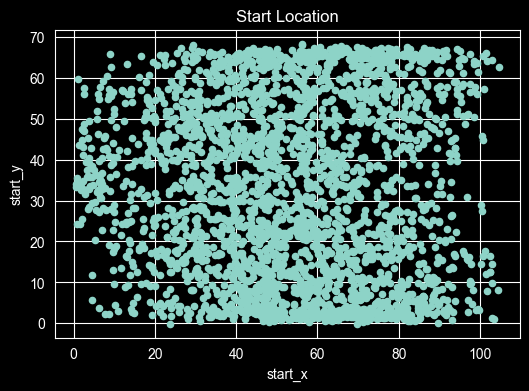

In [11]:
loc_data.plot.scatter(
        x="start_x",
        y="start_y",
        title = f"Start Location",
        figsize = (6,4)
    )
plt.show()

In [12]:
# Gaussian clusters
k_gauss = 4
all_results = []

for init in ["k-means", "k-means", "k-means", "k-means"]:
    times = {}
    results = {}
    models = {}

    for case in ["classic", "bregman"]:
        loc_model = sc.MixtureModel(
            [sc.MultivariateGaussian() for _ in range(k_gauss)],
            init=init
        )
        start = time.time()
        results[case] = loc_model.fit(loc_data, verbose=False, m_step_case=case)
        times[case] = time.time() - start
        models[case] = loc_model

        all_results.append({
            "initialization": init,
            "case": case,
           # "log_likelihood": round(sc.bic_score_mixture(loc_data, loc_model),4),
            "time_sec": times[case],
           # "ch_score": round(sc.kl_ch_score(loc_data, models[case]),6)
        })

loc_results = pd.DataFrame(all_results)
loc_results

,initialization,case,time_sec
0,k-means,classic,1.172536
1,k-means,bregman,0.282342
2,k-means,classic,0.549853
3,k-means,bregman,0.316288
4,random,classic,0.274983
5,random,bregman,0.269009
6,k-means,classic,0.139288
7,k-means,bregman,0.112918


In [13]:
for case in ["classic","bregman"]:
    print(f"{models[case]}\n")

MixtureModel(n_components=4)
  ├─ (0) w=0.376  MultivariateGaussian(d=2, mean=[54.104 16.856], cov=[[482.59 -28.06], [-28.06   71.248]])
  ├─ (1) w=0.115  MultivariateGaussian(d=2, mean=[60.617  2.535], cov=[[337.518  -3.797], [-3.797  1.193]])
  ├─ (2) w=0.409  MultivariateGaussian(d=2, mean=[48.872 47.157], cov=[[579.352  56.162], [ 56.162 103.304]])
  └─ (3) w=0.100  MultivariateGaussian(d=2, mean=[61.83  65.147], cov=[[352.778   3.823], [3.823 1.967]])

MixtureModel(n_components=4)
  ├─ (0) w=0.376  MultivariateGaussian(d=2, mean=[54.104 16.856], cov=[[482.59 -28.06], [-28.06   71.248]])
  ├─ (1) w=0.115  MultivariateGaussian(d=2, mean=[60.617  2.535], cov=[[337.518  -3.797], [-3.797  1.193]])
  ├─ (2) w=0.409  MultivariateGaussian(d=2, mean=[48.872 47.157], cov=[[579.352  56.162], [ 56.162 103.304]])
  └─ (3) w=0.100  MultivariateGaussian(d=2, mean=[61.83  65.147], cov=[[352.778   3.823], [3.823 1.967]])



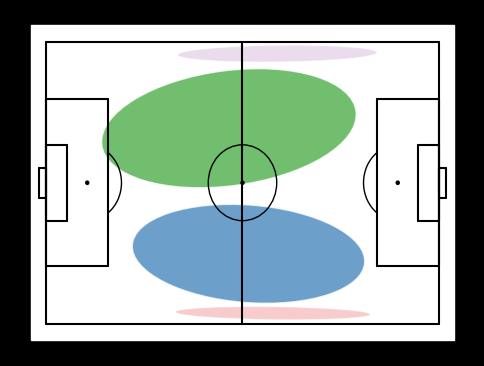

In [14]:
vis.show_location_model(models["classic"])

In [15]:
# Von Mises clusters
k_vm = 3
all_results_vm = []


for init in ["k-means", "k-means", "k-means","k-means"]:
    times = {}
    results = {}
    models = {}

    for case in ["classic", "bregman"]:
        dir_model = sc.MixtureModel(
            [sc.VonMises() for _ in range(k_vm)],
            init=init
        )
        start = time.time()
        results[case] = dir_model.fit(dir_data, verbose=False, m_step_case=case)
        times[case] = time.time() - start
        models[case] = dir_model

        all_results_vm.append({
            "initialization": init,
            "case": case,
           # "log_likelihood": round(sc.bic_score_mixture(dir_data, dir_model),4),
            "time_sec": times[case],
            #"ch_score": round(sc.kl_ch_score(dir_data, models[case]), 6),
        })

dir_results = pd.DataFrame(all_results_vm)
dir_results


,initialization,case,time_sec
0,k-means,classic,0.080791
1,k-means,bregman,0.044408
2,random,classic,0.021535
3,random,bregman,0.009066
4,k-means,classic,0.022421
5,k-means,bregman,0.009559
6,k-means,classic,0.022726
7,k-means,bregman,0.009366


In [16]:
for case in ["classic","bregman"]:
    print(f"{models[case]}\n")

MixtureModel(n_components=3)
  ├─ (0) w=0.331  VonMises(loc=1.6 deg, kappa=0.507)
  ├─ (1) w=0.328  VonMises(loc=4.4 deg, kappa=0.472)
  └─ (2) w=0.340  VonMises(loc=3.6 deg, kappa=0.462)

MixtureModel(n_components=3)
  ├─ (0) w=0.331  VonMises(loc=1.6 deg, kappa=0.507)
  ├─ (1) w=0.328  VonMises(loc=4.4 deg, kappa=0.472)
  └─ (2) w=0.340  VonMises(loc=3.6 deg, kappa=0.462)



### Two layer scheme

Running a Gaussian mixture model to get location clusters. Then, for each one of the location clusters, run a von Mises mixture model using again all dataset, but for this second step, each datapoint is weighted by the posteriors of the location mixture model.

In [26]:
K_loc = 7
K_dir = [2 for _ in range(K_loc)]
init = "k-means"
loc_mixture = sc.MixtureModel(
            [sc.MultivariateGaussian() for _ in range(K_loc)],
            init=init
        )
dir_mixtures = [ sc.MixtureModel(
                    [sc.VonMises() for _ in range(K_dir[j])],
                    init=init
                    )
                 for j in range(K_loc)]

model = sc.TwoLayerMoM(loc_mixture,
                       dir_mixtures)

model.fit(loc_data, dir_data)

142

In [28]:
model.bic_score(loc_data, dir_data)

59485.78541911647

In [29]:
model.completed_bic_score(loc_data, dir_data)

63171.21611990403

In [30]:
loc_data.shape

(2828, 2)

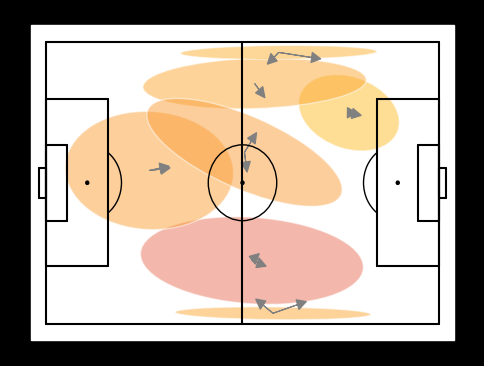

In [31]:
model.plot()

60006.983420041404
62217.59299266831


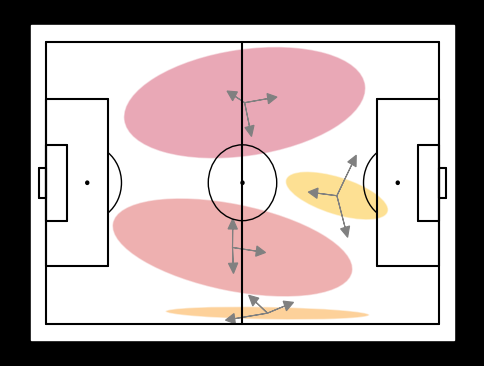

In [32]:
from time import time
K_loc = 4
K_dir = [3 for _ in range(K_loc)]
init = "k-means"
loc_mixture = sc.MixtureModel(
    [sc.MultivariateGaussian() for _ in range(K_loc)],
    init=init
)
dir_mixtures = [sc.MixtureModel(
    [sc.VonMises() for _ in range(K_dir[j])],
    init="k-means"
)
    for j in range(K_loc)]

model = sc.TwoLayerMoM(loc_mixture,
                       dir_mixtures)

model.fit(loc_data, dir_data, c_step_bool=True)
print(model.bic_score(loc_data, dir_data))
print(model.completed_bic_score(loc_data, dir_data))
model.plot()

### One-shot Scheme



In [23]:
oneshot_model = sc.OneShotScheme(n_clusters=30, alpha=1, beta=1, init="k-means")
oneshot_model.fit(loc_data, dir_data, c_step=False)
oneshot_model.bic_score(loc_data, dir_data)


AttributeError: module 'soccer_pattern_recognition' has no attribute 'OneShotScheme'

In [ ]:
oneshot_model.completed_bic_score(loc_data, dir_data)

In [ ]:
oneshot_model.plot()

In [ ]:
oneshot_model = sc.OneShotScheme(n_clusters=30, alpha=1, beta=1, init="k-means")
oneshot_model.fit(loc_data, dir_data, c_step=True)
oneshot_model.bic_score(loc_data, dir_data)

In [ ]:
oneshot_model.completed_bic_score(loc_data, dir_data)

In [ ]:
oneshot_model.plot()